In [14]:
# Install any missing libraries
!pip install xgboost lightgbm plotly -q

print("✅ All libraries installed!")

✅ All libraries installed!


In [15]:
# Core libraries
import numpy as np
import pandas as pd
import random
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Advanced Models
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

# For saving models
import joblib
import pickle

print("✅ All imports successful!")
print(f"Pandas version: {pd.__version__}")

✅ All imports successful!
Pandas version: 2.2.2


In [16]:
# Generate synthetic housing data
print("="*60)
print("GENERATING SYNTHETIC HOUSING DATASET")
print("="*60)

np.random.seed(42)
random.seed(42)

# Number of samples
n_samples = 10000

# Location (city with price multiplier)
cities = ['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Kolkata',
          'Hyderabad', 'Pune', 'Ahmedabad', 'Jaipur', 'Lucknow']
city_multiplier = {
    'Mumbai': 2.5, 'Delhi': 2.2, 'Bangalore': 2.0, 'Chennai': 1.6,
    'Kolkata': 1.4, 'Hyderabad': 1.5, 'Pune': 1.7, 'Ahmedabad': 1.3,
    'Jaipur': 1.2, 'Lucknow': 1.1
}

data = {
    'city': np.random.choice(cities, n_samples),
    'area_sqft': np.random.normal(1500, 500, n_samples).clip(400, 5000),
    'bedrooms': np.random.choice([1,2,3,4,5], n_samples, p=[0.05, 0.25, 0.45, 0.20, 0.05]),
    'bathrooms': np.random.choice([1,2,3,4], n_samples, p=[0.15, 0.50, 0.30, 0.05]),
    'age_years': np.random.exponential(15, n_samples).clip(0, 80),
    'parking': np.random.choice([0,1,2], n_samples, p=[0.30, 0.50, 0.20]),
    'furnishing': np.random.choice(['Fully Furnished', 'Semi Furnished', 'Unfurnished'], n_samples),
    'floor': np.random.choice(['Ground', 'Mid', 'Top'], n_samples),
    'total_floors': np.random.choice([1,2,3,4,5], n_samples, p=[0.10, 0.30, 0.35, 0.20, 0.05]),
    'gym': np.random.choice([0,1], n_samples, p=[0.60, 0.40]),
    'swimming_pool': np.random.choice([0,1], n_samples, p=[0.85, 0.15]),
    'security': np.random.choice([0,1,2], n_samples, p=[0.40, 0.40, 0.20]),
    'near_school': np.random.choice([0,1], n_samples, p=[0.50, 0.50]),
    'near_hospital': np.random.choice([0,1], n_samples, p=[0.55, 0.45]),
    'near_market': np.random.choice([0,1], n_samples, p=[0.45, 0.55]),
}

df = pd.DataFrame(data)

# Add derived features for price calculation
furnishing_map = {'Fully Furnished': 1.25, 'Semi Furnished': 1.10, 'Unfurnished': 1.0}
df['furnishing_multiplier'] = df['furnishing'].map(furnishing_map)

floor_map = {'Ground': 0.95, 'Mid': 1.0, 'Top': 1.08}
df['floor_multiplier'] = df['floor'].map(floor_map)

# Calculate price
base_price = 5000
price_per_sqft = base_price
price_per_sqft *= df['city'].map(city_multiplier)
price_per_sqft *= df['furnishing_multiplier']
price_per_sqft *= df['floor_multiplier']
price_per_sqft *= (1 + df['gym'] * 0.05)
price_per_sqft *= (1 + df['swimming_pool'] * 0.10)
price_per_sqft *= (1 + df['security'] * 0.03)
price_per_sqft *= (1 + df['near_school'] * 0.04)
price_per_sqft *= (1 + df['near_hospital'] * 0.03)
price_per_sqft *= (1 + df['near_market'] * 0.02)

# Age depreciation
age_factor = (1 - np.minimum(df['age_years'] * 0.01, 0.30))
price_per_sqft *= age_factor

# Bedrooms and bathrooms impact
price_per_sqft *= (1 + (df['bedrooms'] - 2) * 0.05)
price_per_sqft *= (1 + (df['bathrooms'] - 2) * 0.04)
price_per_sqft *= (1 + df['parking'] * 0.04)

# Calculate final price
df['price'] = (df['area_sqft'] * price_per_sqft).astype(int)

# Add noise
noise = np.random.normal(1, 0.05, n_samples)
df['price'] = (df['price'] * noise).astype(int)
df['price'] = df['price'].clip(500000, 100000000)

# Drop intermediate columns
df = df.drop(['furnishing_multiplier', 'floor_multiplier'], axis=1)

print(f"\n✅ Dataset created!")
print(f"📊 Shape: {df.shape}")
print(f"📈 Price range: ₹{df['price'].min():,.0f} - ₹{df['price'].max():,.0f}")
print(f"📊 Average price: ₹{df['price'].mean():,.0f}")

# Display first few rows
print("\n📋 First 5 rows:")
df.head()

GENERATING SYNTHETIC HOUSING DATASET

✅ Dataset created!
📊 Shape: (10000, 16)
📈 Price range: ₹1,807,180 - ₹61,953,789
📊 Average price: ₹14,897,674

📋 First 5 rows:


,city,area_sqft,bedrooms,bathrooms,age_years,parking,furnishing,floor,total_floors,gym,swimming_pool,security,near_school,near_hospital,near_market,price
0,Pune,895.400644,1,1,5.839127,1,Semi Furnished,Ground,2,0,0,1,1,1,1,8326433
1,Chennai,1528.370842,3,1,18.405492,1,Semi Furnished,Mid,4,0,0,0,0,0,1,11185277
2,Ahmedabad,1556.728020,3,1,46.392300,1,Semi Furnished,Ground,1,0,0,0,1,1,1,8128740
3,Kolkata,1592.918814,3,2,10.658944,0,Semi Furnished,Ground,4,1,0,0,1,1,1,12561542
4,Pune,1959.935758,3,2,10.624986,1,Unfurnished,Ground,2,0,0,2,0,1,0,16147542


In [17]:
# Create directories for saving outputs
!mkdir -p outputs/graphs
!mkdir -p models
!mkdir -p data

print("✅ Directory structure created!")
print("📁 outputs/graphs/ - For saving charts")
print("📁 models/ - For saving trained models")
print("📁 data/ - For saving datasets")

✅ Directory structure created!
📁 outputs/graphs/ - For saving charts
📁 models/ - For saving trained models
📁 data/ - For saving datasets


In [18]:
# Save dataset to Colab's local storage
df.to_csv('data/housing_data.csv', index=False)
print("✅ Dataset saved to 'data/housing_data.csv'")

# Display dataset info
print(f"\n📊 Dataset saved with {len(df)} rows and {len(df.columns)} columns")

✅ Dataset saved to 'data/housing_data.csv'

📊 Dataset saved with 10000 rows and 16 columns


In [19]:
print("="*60)
print("DATA EXPLORATION")
print("="*60)

# Basic info
print("\n📊 Dataset Info:")
print("-"*40)
buffer = df.dtypes.to_string()
print("Data Types:")
print(df.dtypes.value_counts())

print("\n📊 Statistical Summary:")
print("-"*40)
display(df.describe())

print("\n📊 Missing Values:")
print("-"*40)
print(df.isnull().sum())

print("\n📊 Data Types Count:")
print("-"*40)
print(df.dtypes.value_counts())

DATA EXPLORATION

📊 Dataset Info:
----------------------------------------
Data Types:
int64      11
object      3
float64     2
Name: count, dtype: int64

📊 Statistical Summary:
----------------------------------------


,area_sqft,bedrooms,bathrooms,age_years,parking,total_floors,gym,swimming_pool,security,near_school,near_hospital,near_market,price
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04
mean,1505.503754,2.949900,2.247700,14.810331,0.906000,2.806100,0.399300,0.146900,0.810000,0.496800,0.447600,0.558900,1.489767e+07
std,495.518450,0.913824,0.768377,14.613492,0.695135,1.021375,0.489779,0.354024,0.751769,0.500015,0.497272,0.496543,7.076990e+06
min,400.000000,1.000000,1.000000,0.000251,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.807180e+06
25%,1165.732129,2.000000,2.000000,4.181860,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.884908e+06
50%,1500.214494,3.000000,2.000000,10.241841,1.000000,3.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.369023e+07
75%,1842.814314,3.000000,3.000000,20.768272,1.000000,4.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.859315e+07
max,3739.542126,5.000000,4.000000,80.000000,2.000000,5.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,6.195379e+07



📊 Missing Values:
----------------------------------------
city             0
area_sqft        0
bedrooms         0
bathrooms        0
age_years        0
parking          0
furnishing       0
floor            0
total_floors     0
gym              0
swimming_pool    0
security         0
near_school      0
near_hospital    0
near_market      0
price            0
dtype: int64

📊 Data Types Count:
----------------------------------------
int64      11
object      3
float64     2
Name: count, dtype: int64


In [20]:
print("="*60)
print("DATA CLEANING")
print("="*60)

# Make a copy
df_clean = df.copy()

# Check for duplicates
duplicates = df_clean.duplicated().sum()
print(f"\n🔍 Duplicate rows: {duplicates}")
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"✅ Removed {duplicates} duplicates")

# Handle outliers in price and area
def handle_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)].shape[0]
    df[column] = df[column].clip(lower, upper)
    return df, outliers

df_clean, price_outliers = handle_outliers(df_clean, 'price')
df_clean, area_outliers = handle_outliers(df_clean, 'area_sqft')

print(f"\n✅ Capped {price_outliers} price outliers")
print(f"✅ Capped {area_outliers} area outliers")

print(f"\n✅ Final dataset shape: {df_clean.shape}")

# Save cleaned data
df_clean.to_csv('data/cleaned_housing.csv', index=False)
print("\n✅ Cleaned data saved to 'data/cleaned_housing.csv'")

DATA CLEANING

🔍 Duplicate rows: 0

✅ Capped 279 price outliers
✅ Capped 33 area outliers

✅ Final dataset shape: (10000, 16)

✅ Cleaned data saved to 'data/cleaned_housing.csv'


EXPLORATORY DATA ANALYSIS


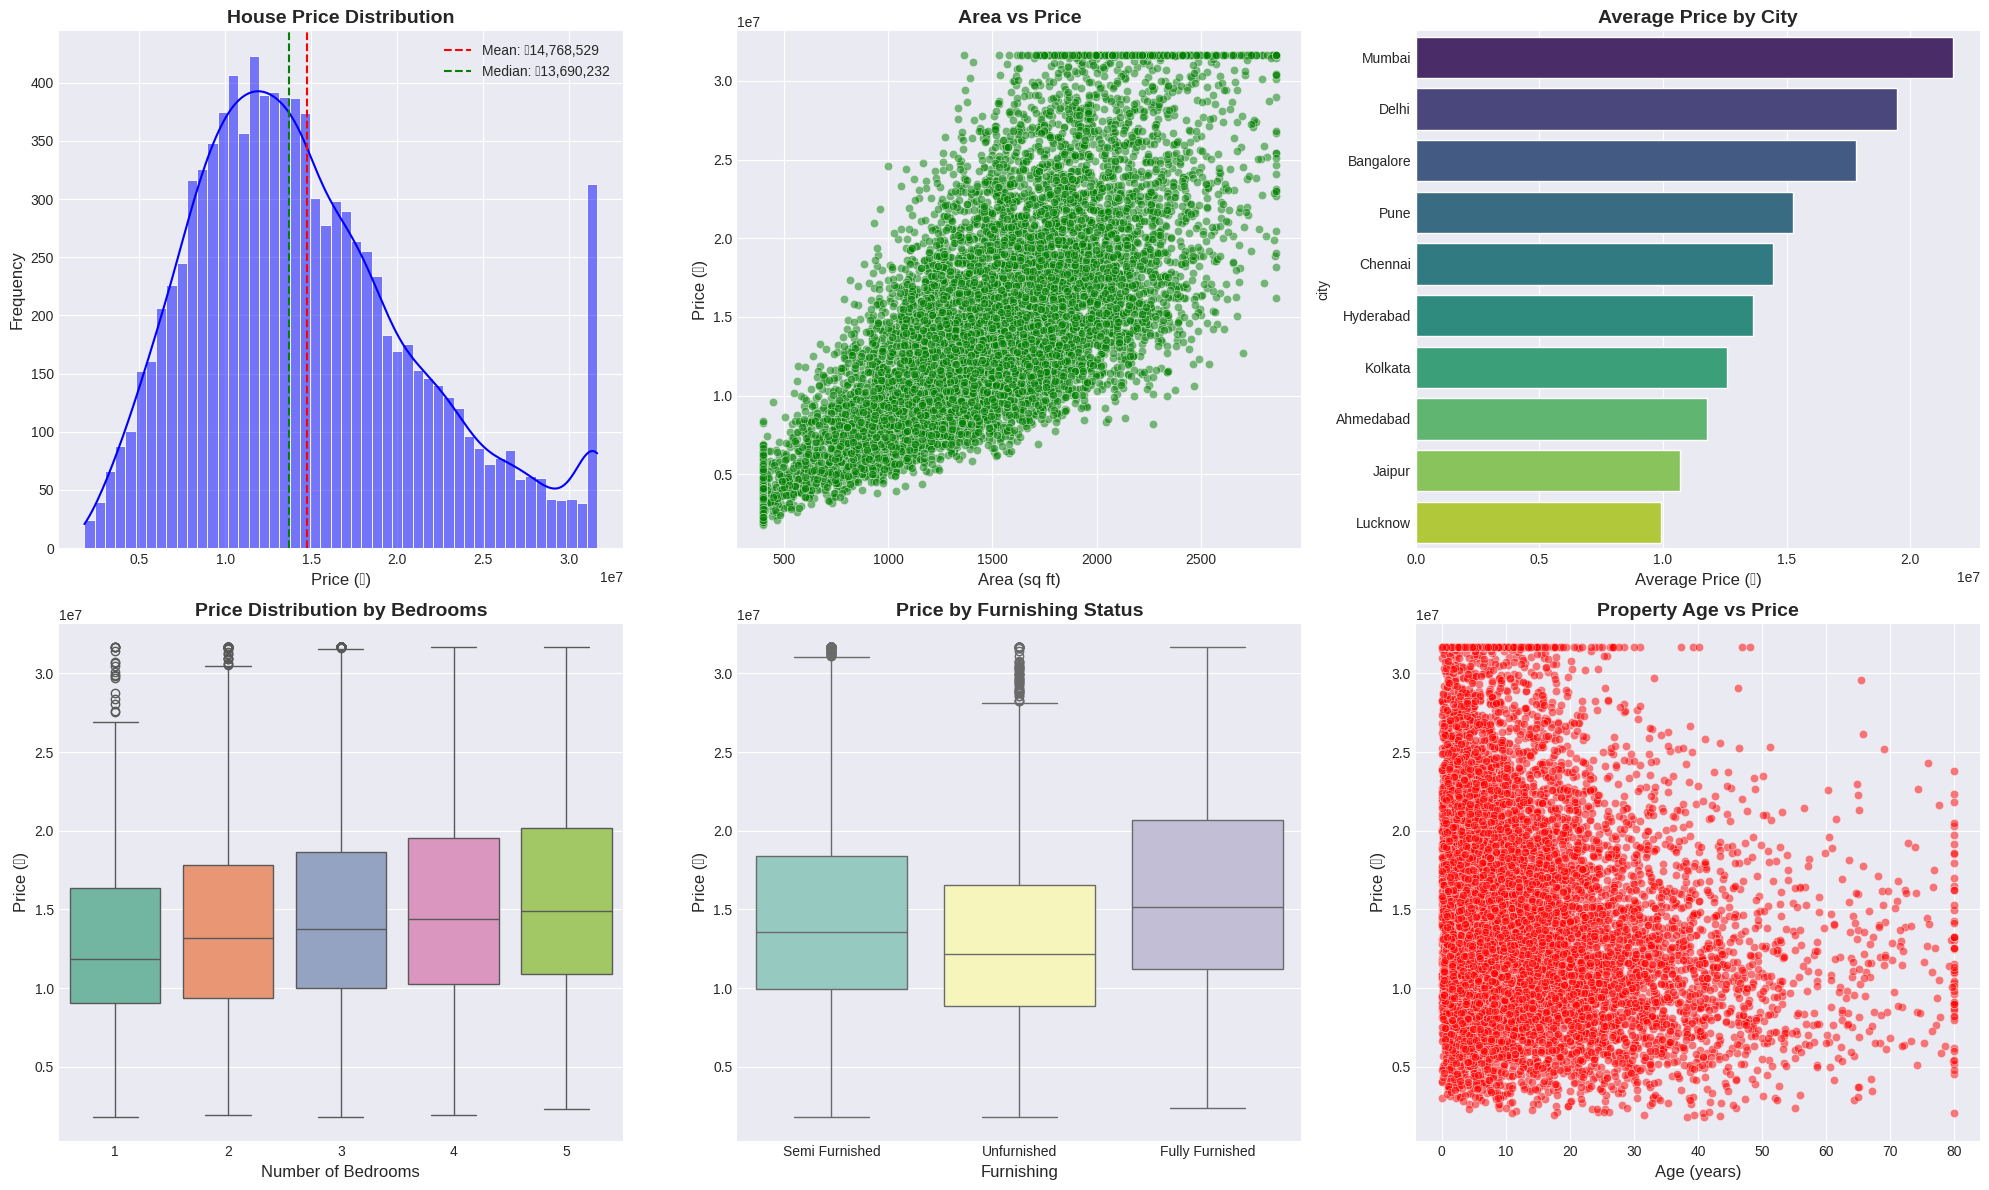

✅ EDA Overview saved to 'outputs/graphs/eda_overview.png'


In [21]:
print("="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# Set style
sns.set_style("whitegrid")
plt.style.use('seaborn-v0_8-darkgrid')

# Create figure with subplots
fig = plt.figure(figsize=(20, 12))

# 1. Price Distribution
ax1 = fig.add_subplot(2, 3, 1)
sns.histplot(df_clean['price'], bins=50, kde=True, color='blue', ax=ax1)
ax1.set_title('House Price Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Price (₹)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.axvline(df_clean['price'].mean(), color='red', linestyle='--', label=f'Mean: ₹{df_clean["price"].mean():,.0f}')
ax1.axvline(df_clean['price'].median(), color='green', linestyle='--', label=f'Median: ₹{df_clean["price"].median():,.0f}')
ax1.legend()

# 2. Area vs Price
ax2 = fig.add_subplot(2, 3, 2)
sns.scatterplot(data=df_clean, x='area_sqft', y='price', alpha=0.5, color='green', ax=ax2)
ax2.set_title('Area vs Price', fontsize=14, fontweight='bold')
ax2.set_xlabel('Area (sq ft)', fontsize=12)
ax2.set_ylabel('Price (₹)', fontsize=12)

# 3. Price by City
ax3 = fig.add_subplot(2, 3, 3)
city_price = df_clean.groupby('city')['price'].mean().sort_values(ascending=False)
sns.barplot(x=city_price.values, y=city_price.index, palette='viridis', ax=ax3)
ax3.set_title('Average Price by City', fontsize=14, fontweight='bold')
ax3.set_xlabel('Average Price (₹)', fontsize=12)

# 4. Price by Bedrooms
ax4 = fig.add_subplot(2, 3, 4)
sns.boxplot(data=df_clean, x='bedrooms', y='price', palette='Set2', ax=ax4)
ax4.set_title('Price Distribution by Bedrooms', fontsize=14, fontweight='bold')
ax4.set_xlabel('Number of Bedrooms', fontsize=12)
ax4.set_ylabel('Price (₹)', fontsize=12)

# 5. Price by Furnishing
ax5 = fig.add_subplot(2, 3, 5)
sns.boxplot(data=df_clean, x='furnishing', y='price', palette='Set3', ax=ax5)
ax5.set_title('Price by Furnishing Status', fontsize=14, fontweight='bold')
ax5.set_xlabel('Furnishing', fontsize=12)
ax5.set_ylabel('Price (₹)', fontsize=12)

# 6. Age vs Price
ax6 = fig.add_subplot(2, 3, 6)
sns.scatterplot(data=df_clean, x='age_years', y='price', alpha=0.5, color='red', ax=ax6)
ax6.set_title('Property Age vs Price', fontsize=14, fontweight='bold')
ax6.set_xlabel('Age (years)', fontsize=12)
ax6.set_ylabel('Price (₹)', fontsize=12)

plt.tight_layout()
plt.savefig('outputs/graphs/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA Overview saved to 'outputs/graphs/eda_overview.png'")

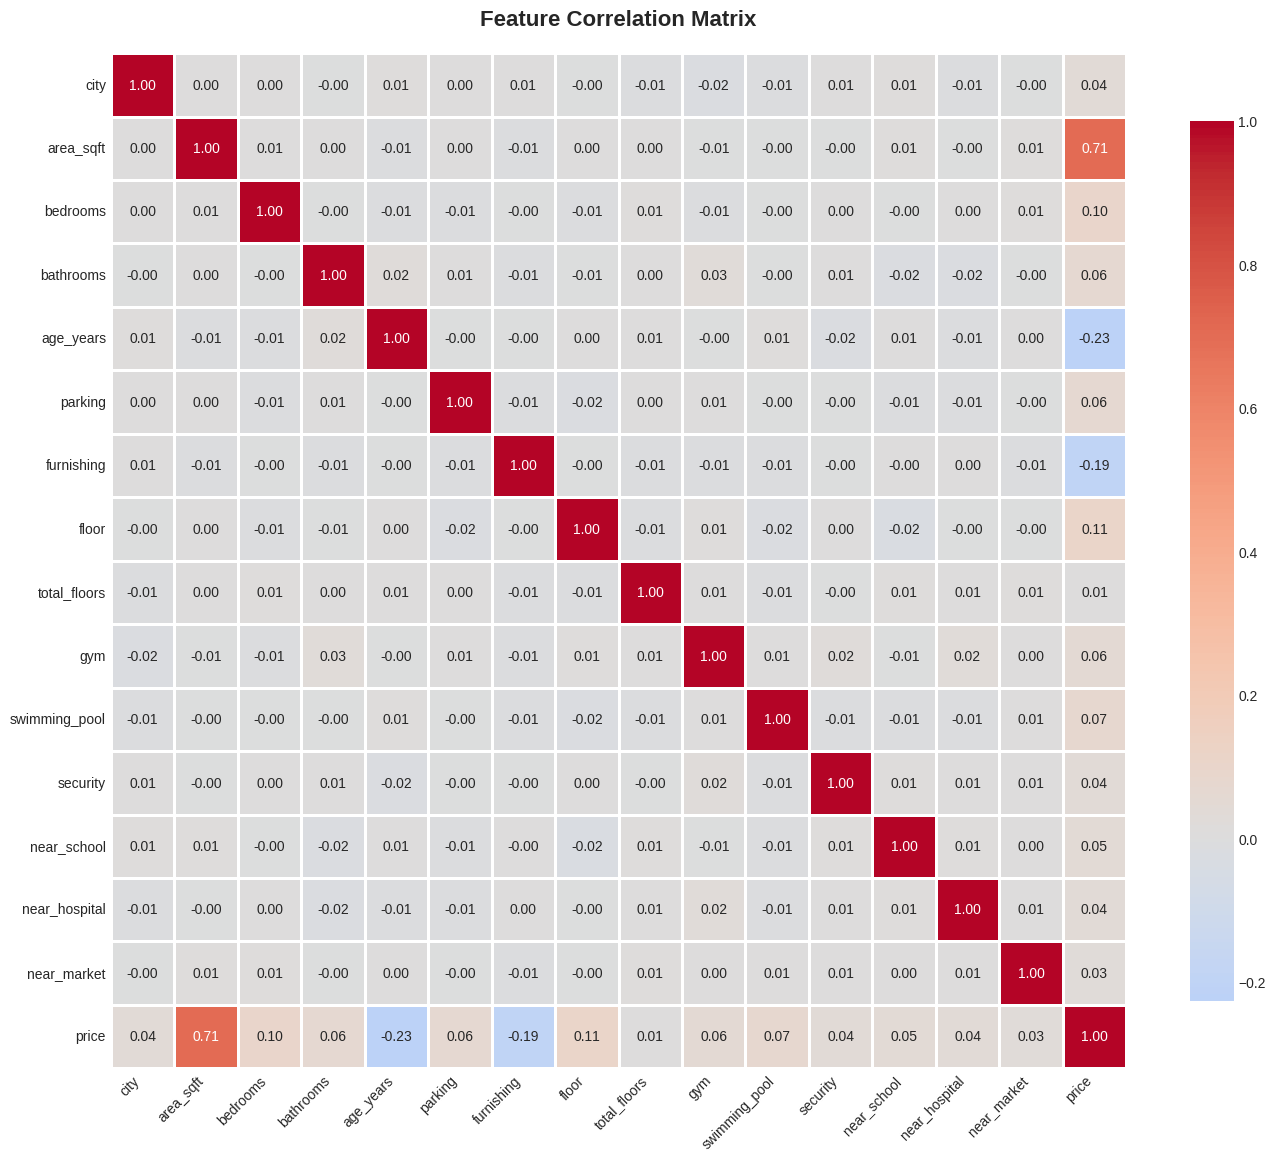


📊 Top Features Correlated with Price:
----------------------------------------
area_sqft            : 0.706
floor                : 0.109
bedrooms             : 0.096
swimming_pool        : 0.071
parking              : 0.065
bathrooms            : 0.064
gym                  : 0.057
near_school          : 0.047
security             : 0.042
near_hospital        : 0.039
city                 : 0.037
near_market          : 0.033
total_floors         : 0.007
furnishing           : -0.194
age_years            : -0.225


In [22]:
# Encode categorical for correlation
df_corr = df_clean.copy()

# Label encode categorical columns
categorical_cols = ['city', 'furnishing', 'floor']
for col in categorical_cols:
    le = LabelEncoder()
    df_corr[col] = le.fit_transform(df_corr[col])

# Select numeric columns
numeric_cols = df_corr.select_dtypes(include=[np.number]).columns
correlation_matrix = df_corr[numeric_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('outputs/graphs/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with price
price_corr = correlation_matrix['price'].sort_values(ascending=False)
print("\n📊 Top Features Correlated with Price:")
print("-"*40)
for feature, corr in price_corr.items():
    if feature != 'price':
        print(f"{feature:20} : {corr:.3f}")

In [23]:
print("="*60)
print("FEATURE ENGINEERING")
print("="*60)

df_model = df_clean.copy()

# 1. Price per square foot
df_model['price_per_sqft'] = df_model['price'] / df_model['area_sqft']

# 2. Bathroom to bedroom ratio
df_model['bathroom_bedroom_ratio'] = df_model['bathrooms'] / df_model['bedrooms']

# 3. Total rooms
df_model['total_rooms'] = df_model['bedrooms'] + df_model['bathrooms']

# 4. Luxury score (based on amenities)
df_model['luxury_score'] = (
    df_model['gym'] * 0.25 +
    df_model['swimming_pool'] * 0.35 +
    df_model['security'] * 0.2 +
    df_model['parking'] * 0.2
)

# 5. Location score
df_model['location_score'] = (
    df_model['near_school'] * 0.4 +
    df_model['near_hospital'] * 0.3 +
    df_model['near_market'] * 0.3
)

# 6. Area per bedroom
df_model['area_per_bedroom'] = df_model['area_sqft'] / df_model['bedrooms']

print(f"\n✅ Added {6} new features")
print(f"📊 New features: price_per_sqft, bathroom_bedroom_ratio, total_rooms, luxury_score, location_score, area_per_bedroom")

print(f"\n📊 Updated dataset shape: {df_model.shape}")
df_model.head()

FEATURE ENGINEERING

✅ Added 6 new features
📊 New features: price_per_sqft, bathroom_bedroom_ratio, total_rooms, luxury_score, location_score, area_per_bedroom

📊 Updated dataset shape: (10000, 22)


,city,area_sqft,bedrooms,bathrooms,age_years,parking,furnishing,floor,total_floors,gym,...,near_school,near_hospital,near_market,price,price_per_sqft,bathroom_bedroom_ratio,total_rooms,luxury_score,location_score,area_per_bedroom
0,Pune,895.400644,1,1,5.839127,1,Semi Furnished,Ground,2,0,...,1,1,1,8326433.0,9299.114371,1.000000,2,0.40,1.0,895.400644
1,Chennai,1528.370842,3,1,18.405492,1,Semi Furnished,Mid,4,0,...,0,0,1,11185277.0,7318.431296,0.333333,4,0.20,0.3,509.456947
2,Ahmedabad,1556.728020,3,1,46.392300,1,Semi Furnished,Ground,1,0,...,1,1,1,8128740.0,5221.682847,0.333333,4,0.20,1.0,518.909340
3,Kolkata,1592.918814,3,2,10.658944,0,Semi Furnished,Ground,4,1,...,1,1,1,12561542.0,7885.864544,0.666667,5,0.25,1.0,530.972938
4,Pune,1959.935758,3,2,10.624986,1,Unfurnished,Ground,2,0,...,0,1,0,16147542.0,8238.811877,0.666667,5,0.60,0.3,653.311919


In [24]:
print("="*60)
print("DATA PREPARATION FOR MODELING")
print("="*60)

# Select features for modeling
feature_columns = [
    'area_sqft', 'bedrooms', 'bathrooms', 'age_years', 'parking',
    'total_floors', 'gym', 'swimming_pool', 'security',
    'near_school', 'near_hospital', 'near_market',
    'bathroom_bedroom_ratio', 'total_rooms', 'luxury_score',
    'location_score', 'area_per_bedroom'
]

# Add categorical features (will be encoded)
categorical_features = ['city', 'furnishing', 'floor']

X = df_model[feature_columns + categorical_features].copy()
y = df_model['price']

print(f"📊 Feature matrix shape: {X.shape}")
print(f"📊 Target shape: {y.shape}")

# Encode categorical variables
print("\n🔄 Encoding categorical variables...")
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    print(f"   Encoded {col}: {dict(zip(le.classes_, range(len(le.classes_))))}")

# Scale numerical features
print("\n📏 Scaling numerical features...")
numerical_features = feature_columns
scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])

print("✅ Features scaled")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n📊 Train set: {X_train.shape[0]} samples")
print(f"📊 Test set: {X_test.shape[0]} samples")

DATA PREPARATION FOR MODELING
📊 Feature matrix shape: (10000, 20)
📊 Target shape: (10000,)

🔄 Encoding categorical variables...
   Encoded city: {'Ahmedabad': 0, 'Bangalore': 1, 'Chennai': 2, 'Delhi': 3, 'Hyderabad': 4, 'Jaipur': 5, 'Kolkata': 6, 'Lucknow': 7, 'Mumbai': 8, 'Pune': 9}
   Encoded furnishing: {'Fully Furnished': 0, 'Semi Furnished': 1, 'Unfurnished': 2}
   Encoded floor: {'Ground': 0, 'Mid': 1, 'Top': 2}

📏 Scaling numerical features...
✅ Features scaled

📊 Train set: 8000 samples
📊 Test set: 2000 samples


In [25]:
print("="*60)
print("MODEL TRAINING")
print("="*60)

# Dictionary to store models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.001),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0, n_jobs=-1)
}

# Train and evaluate
results = []
trained_models = {}

for name, model in models.items():
    print(f"\n🚀 Training {name}...")

    # Train
    model.fit(X_train, y_train)
    trained_models[name] = model

    # Predict
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Calculate metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    r2 = r2_score(y_test, y_pred_test)

    results.append({
        'Model': name,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train MAE': train_mae,
        'Test MAE': test_mae,
        'R² Score': r2
    })

    print(f"   ✅ Train RMSE: ₹{train_rmse:,.0f}")
    print(f"   ✅ Test RMSE: ₹{test_rmse:,.0f}")
    print(f"   ✅ R² Score: {r2:.4f}")

# Create results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test RMSE')

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
display(results_df)

# Save results
results_df.to_csv('outputs/model_comparison.csv', index=False)
print("\n✅ Results saved to 'outputs/model_comparison.csv'")

MODEL TRAINING

🚀 Training Linear Regression...
   ✅ Train RMSE: ₹4,085,479
   ✅ Test RMSE: ₹4,084,655
   ✅ R² Score: 0.6104

🚀 Training Ridge Regression...
   ✅ Train RMSE: ₹4,085,479
   ✅ Test RMSE: ₹4,084,692
   ✅ R² Score: 0.6104

🚀 Training Lasso Regression...
   ✅ Train RMSE: ₹4,085,479
   ✅ Test RMSE: ₹4,084,655
   ✅ R² Score: 0.6104

🚀 Training Decision Tree...
   ✅ Train RMSE: ₹0
   ✅ Test RMSE: ₹2,438,393
   ✅ R² Score: 0.8612

🚀 Training Random Forest...
   ✅ Train RMSE: ₹574,698
   ✅ Test RMSE: ₹1,518,721
   ✅ R² Score: 0.9461

🚀 Training Gradient Boosting...
   ✅ Train RMSE: ₹1,413,459
   ✅ Test RMSE: ₹1,539,686
   ✅ R² Score: 0.9447

🚀 Training XGBoost...
   ✅ Train RMSE: ₹523,659
   ✅ Test RMSE: ₹1,179,485
   ✅ R² Score: 0.9675

MODEL COMPARISON


,Model,Train RMSE,Test RMSE,Train MAE,Test MAE,R² Score
6,XGBoost,5.236587e+05,1.179485e+06,3.880540e+05,8.743125e+05,0.967518
4,Random Forest,5.746984e+05,1.518721e+06,4.278339e+05,1.142935e+06,0.946147
5,Gradient Boosting,1.413459e+06,1.539686e+06,1.049293e+06,1.144597e+06,0.944650
3,Decision Tree,0.000000e+00,2.438393e+06,0.000000e+00,1.799001e+06,0.861177
0,Linear Regression,4.085479e+06,4.084655e+06,3.301307e+06,3.301911e+06,0.610450
2,Lasso Regression,4.085479e+06,4.084655e+06,3.301307e+06,3.301911e+06,0.610450
1,Ridge Regression,4.085479e+06,4.084692e+06,3.301304e+06,3.301920e+06,0.610443



✅ Results saved to 'outputs/model_comparison.csv'


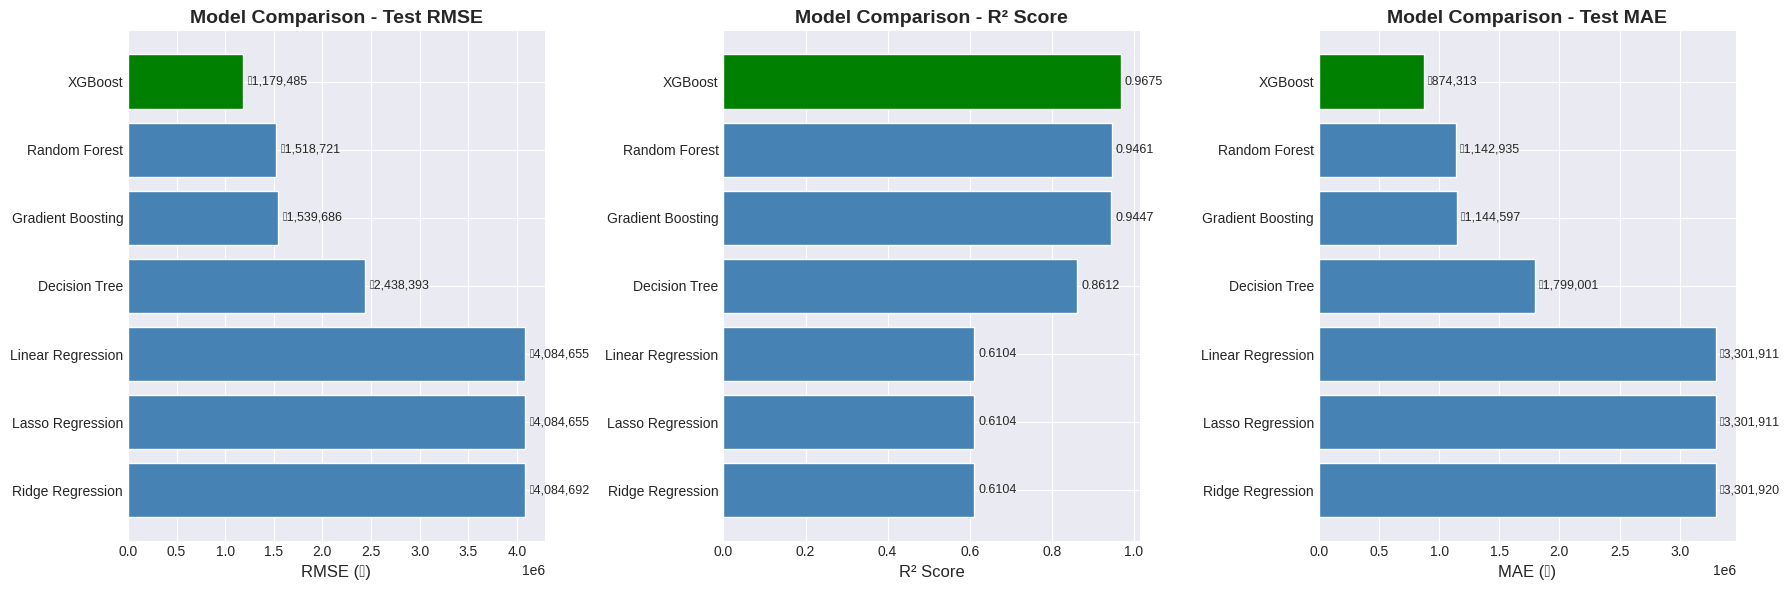

✅ Model comparison saved to 'outputs/graphs/model_comparison.png'


In [26]:
# Plot model comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# RMSE Comparison
ax1 = axes[0]
colors = ['green' if x == results_df['Test RMSE'].min() else 'steelblue' for x in results_df['Test RMSE']]
bars1 = ax1.barh(results_df['Model'], results_df['Test RMSE'], color=colors)
ax1.set_xlabel('RMSE (₹)', fontsize=12)
ax1.set_title('Model Comparison - Test RMSE', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
# Add value labels
for i, (bar, val) in enumerate(zip(bars1, results_df['Test RMSE'])):
    ax1.text(val + 50000, bar.get_y() + bar.get_height()/2, f'₹{val:,.0f}', va='center', fontsize=9)

# MAE Comparison
ax2 = axes[2]
colors = ['green' if x == results_df['Test MAE'].min() else 'steelblue' for x in results_df['Test MAE']]
bars2 = ax2.barh(results_df['Model'], results_df['Test MAE'], color=colors)
ax2.set_xlabel('MAE (₹)', fontsize=12)
ax2.set_title('Model Comparison - Test MAE', fontsize=14, fontweight='bold')
ax2.invert_yaxis()
for i, (bar, val) in enumerate(zip(bars2, results_df['Test MAE'])):
    ax2.text(val + 30000, bar.get_y() + bar.get_height()/2, f'₹{val:,.0f}', va='center', fontsize=9)

# R² Score Comparison
ax3 = axes[1]
colors = ['green' if x == results_df['R² Score'].max() else 'steelblue' for x in results_df['R² Score']]
bars3 = ax3.barh(results_df['Model'], results_df['R² Score'], color=colors)
ax3.set_xlabel('R² Score', fontsize=12)
ax3.set_title('Model Comparison - R² Score', fontsize=14, fontweight='bold')
ax3.invert_yaxis()
for i, (bar, val) in enumerate(zip(bars3, results_df['R² Score'])):
    ax3.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/graphs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Model comparison saved to 'outputs/graphs/model_comparison.png'")

BEST MODEL: XGBoost


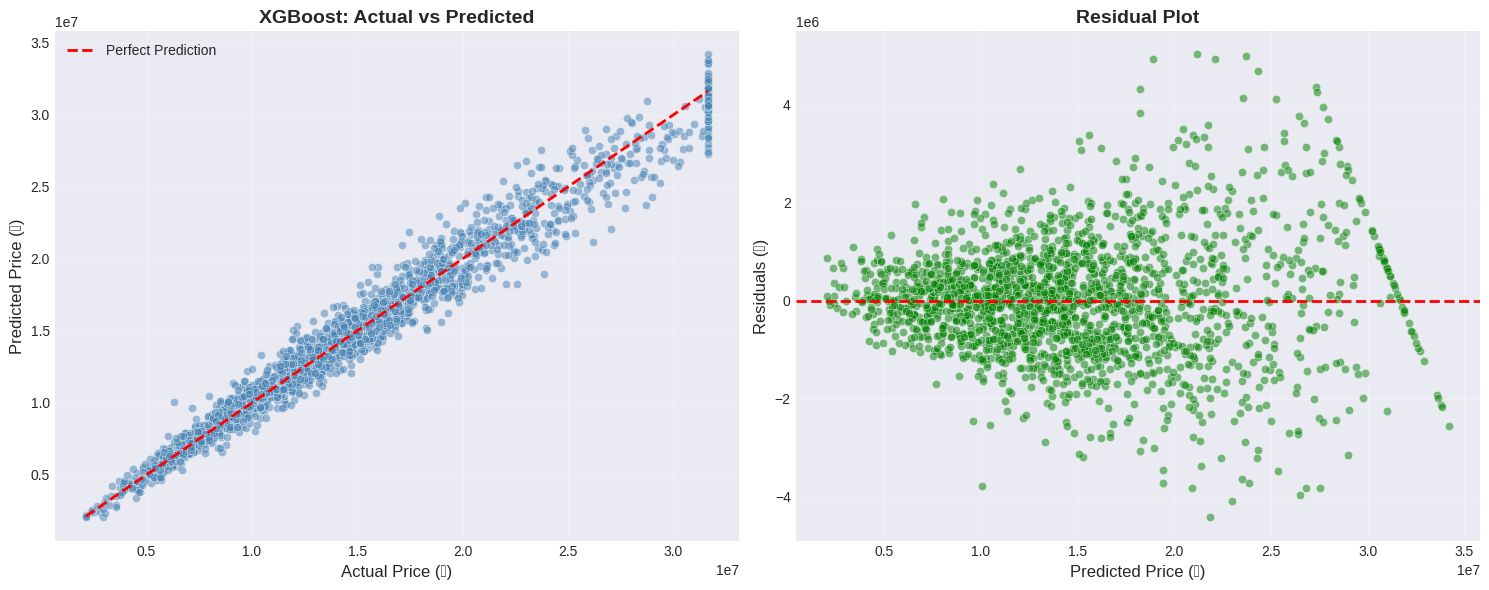


📊 Model Performance Metrics:
----------------------------------------
RMSE: ₹1,179,485
MAE: ₹874,313
R² Score: 0.9675
MAPE: 6.12%


In [27]:
# Get best model
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print("="*60)
print(f"BEST MODEL: {best_model_name}")
print("="*60)

# Predict on test set
y_pred = best_model.predict(X_test)

# Actual vs Predicted plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot
ax1 = axes[0]
ax1.scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.5)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Price (₹)', fontsize=12)
ax1.set_ylabel('Predicted Price (₹)', fontsize=12)
ax1.set_title(f'{best_model_name}: Actual vs Predicted', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Residual plot
ax2 = axes[1]
residuals = y_test - y_pred
ax2.scatter(y_pred, residuals, alpha=0.5, color='green', edgecolors='white', linewidth=0.5)
ax2.axhline(y=0, color='red', linestyle='--', lw=2)
ax2.set_xlabel('Predicted Price (₹)', fontsize=12)
ax2.set_ylabel('Residuals (₹)', fontsize=12)
ax2.set_title('Residual Plot', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/graphs/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

# Print metrics
print(f"\n📊 Model Performance Metrics:")
print("-"*40)
print(f"RMSE: ₹{np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
print(f"MAE: ₹{mean_absolute_error(y_test, y_pred):,.0f}")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAPE: {(np.abs((y_test - y_pred) / y_test).mean() * 100):.2f}%")

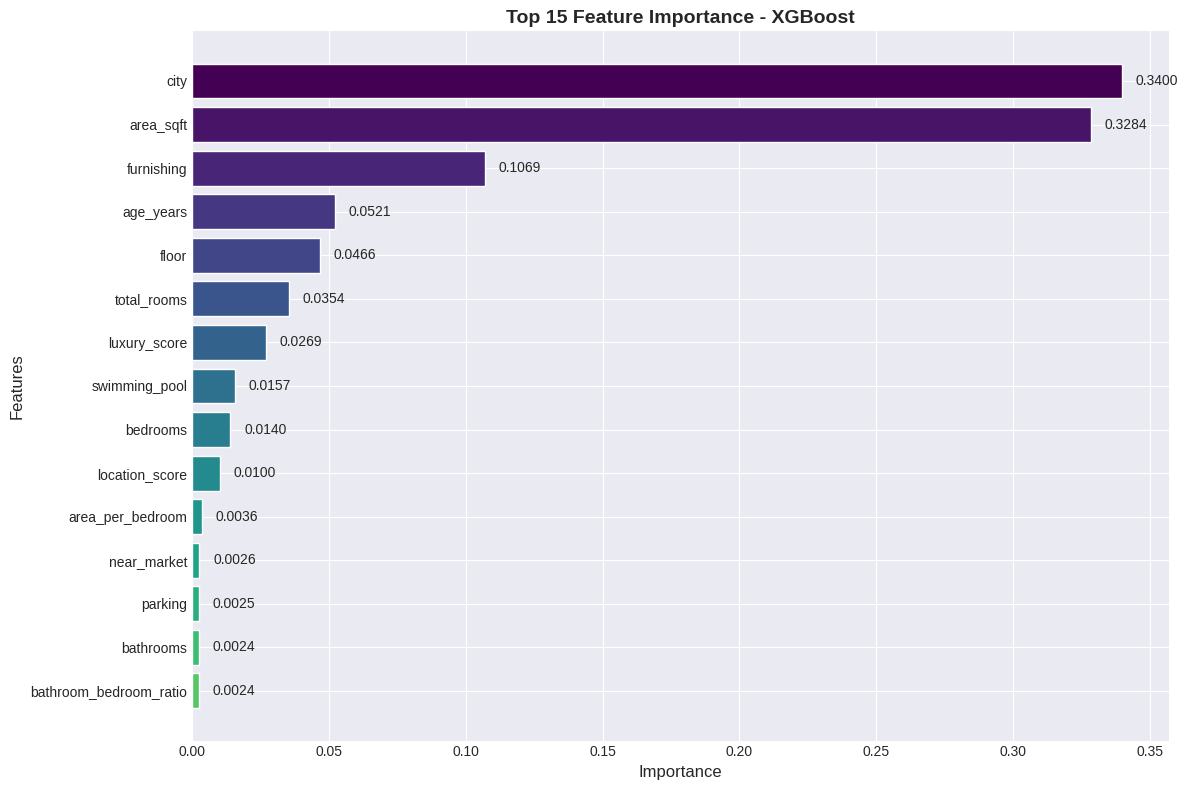


📊 Top 10 Most Important Features:
----------------------------------------


,Feature,Importance
17,city,0.339999
0,area_sqft,0.328419
18,furnishing,0.106869
3,age_years,0.052109
19,floor,0.046613
13,total_rooms,0.035380
14,luxury_score,0.026927
7,swimming_pool,0.015691
1,bedrooms,0.013951
15,location_score,0.010031


In [28]:
# Get feature importance from best model if it supports it
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    # Plot feature importance
    plt.figure(figsize=(12, 8))
    colors = plt.cm.viridis(np.linspace(0, 1, len(feature_importance)))
    bars = plt.barh(feature_importance['Feature'][:15], feature_importance['Importance'][:15], color=colors)
    plt.xlabel('Importance', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.title(f'Top 15 Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()

    # Add value labels
    for bar, val in zip(bars, feature_importance['Importance'][:15]):
        plt.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10)

    plt.tight_layout()
    plt.savefig('outputs/graphs/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n📊 Top 10 Most Important Features:")
    print("-"*40)
    display(feature_importance.head(10))

    # Save feature importance
    feature_importance.to_csv('outputs/feature_importance.csv', index=False)

else:
    print(f"{best_model_name} doesn't provide feature importance")

    # Use Linear Regression coefficients as alternative
    if hasattr(best_model, 'coef_'):
        feature_importance = pd.DataFrame({
            'Feature': X.columns,
            'Coefficient': best_model.coef_
        }).sort_values('Coefficient', ascending=False)

        print("\n📊 Top Features by Coefficient Magnitude:")
        display(feature_importance.head(10))

CROSS-VALIDATION

📊 5-Fold Cross-Validation Results:
----------------------------------------
Fold 1: R² = 0.9675
Fold 2: R² = 0.9700
Fold 3: R² = 0.9703
Fold 4: R² = 0.9676
Fold 5: R² = 0.9673

📈 Mean R²: 0.9685 (+/- 0.0026)


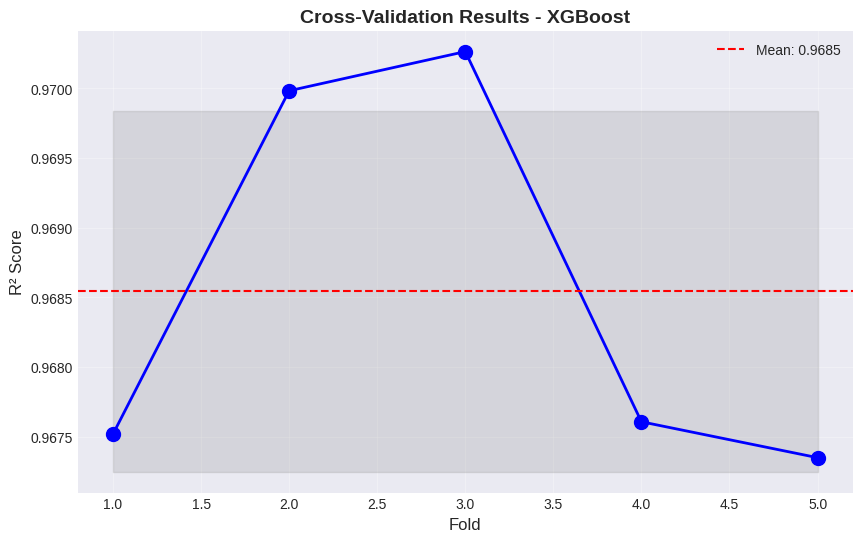

In [29]:
print("="*60)
print("CROSS-VALIDATION")
print("="*60)

# Perform 5-fold cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X, y, cv=kfold, scoring='r2', n_jobs=-1)

print(f"\n📊 5-Fold Cross-Validation Results:")
print("-"*40)
for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: R² = {score:.4f}")

print(f"\n📈 Mean R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Plot CV results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 6), cv_scores, 'bo-', linewidth=2, markersize=10)
plt.axhline(y=cv_scores.mean(), color='r', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
plt.fill_between(range(1, 6), cv_scores.mean() - cv_scores.std(), cv_scores.mean() + cv_scores.std(), alpha=0.2, color='gray')
plt.xlabel('Fold', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title(f'Cross-Validation Results - {best_model_name}', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('outputs/graphs/cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Save the best model and preprocessing objects
model_path = 'models/best_model.pkl'
preprocessor_path = 'models/preprocessor.pkl'

# Save model
joblib.dump(best_model, model_path)
print(f"✅ Model saved to: {model_path}")

# Save preprocessor objects
preprocessor = {
    'scaler': scaler,
    'label_encoders': label_encoders,
    'feature_columns': feature_columns,
    'categorical_features': categorical_features,
    'best_model_name': best_model_name
}
joblib.dump(preprocessor, preprocessor_path)
print(f"✅ Preprocessor saved to: {preprocessor_path}")

print("\n✅ All artifacts saved successfully!")

✅ Model saved to: models/best_model.pkl
✅ Preprocessor saved to: models/preprocessor.pkl

✅ All artifacts saved successfully!


In [31]:
def predict_house_price(area_sqft, bedrooms, bathrooms, age_years, parking,
                        total_floors, gym, swimming_pool, security,
                        near_school, near_hospital, near_market,
                        city, furnishing, floor):
    """
    Predict house price based on input features
    """
    # Create input dataframe
    input_data = pd.DataFrame({
        'area_sqft': [area_sqft],
        'bedrooms': [bedrooms],
        'bathrooms': [bathrooms],
        'age_years': [age_years],
        'parking': [parking],
        'total_floors': [total_floors],
        'gym': [gym],
        'swimming_pool': [swimming_pool],
        'security': [security],
        'near_school': [near_school],
        'near_hospital': [near_hospital],
        'near_market': [near_market],
        'city': [city],
        'furnishing': [furnishing],
        'floor': [floor]
    })

    # Add engineered features
    input_data['bathroom_bedroom_ratio'] = input_data['bathrooms'] / input_data['bedrooms']
    input_data['total_rooms'] = input_data['bedrooms'] + input_data['bathrooms']
    input_data['luxury_score'] = (
        input_data['gym'] * 0.25 +
        input_data['swimming_pool'] * 0.35 +
        input_data['security'] * 0.2 +
        input_data['parking'] * 0.2
    )
    input_data['location_score'] = (
        input_data['near_school'] * 0.4 +
        input_data['near_hospital'] * 0.3 +
        input_data['near_market'] * 0.3
    )
    input_data['area_per_bedroom'] = input_data['area_sqft'] / input_data['bedrooms']

    # Encode categorical
    for col in categorical_features:
        le = label_encoders[col]
        input_data[col] = le.transform(input_data[col])

    # Scale numerical features
    input_data[feature_columns] = scaler.transform(input_data[feature_columns])

    # Predict
    prediction = best_model.predict(input_data[feature_columns + categorical_features])

    return prediction[0]

print("✅ Prediction function created!")

✅ Prediction function created!


In [34]:
print("="*60)
print("TEST PREDICTIONS")
print("="*60)

# Test Case 1: Luxury apartment in Mumbai
price1 = predict_house_price(
    area_sqft=2500, bedrooms=4, bathrooms=3, age_years=2, parking=2,
    total_floors=15, gym=1, swimming_pool=1, security=2,
    near_school=1, near_hospital=1, near_market=1,
    city='Mumbai', furnishing='Fully Furnished', floor='Top'
)

# Test Case 2: Budget apartment in Jaipur (FIXED: changed 'furnishment' to 'furnishing')
price2 = predict_house_price(
    area_sqft=800, bedrooms=2, bathrooms=1, age_years=15, parking=1,
    total_floors=3, gym=0, swimming_pool=0, security=0,
    near_school=0, near_hospital=0, near_market=1,
    city='Jaipur', furnishing='Unfurnished', floor='Ground'  # ← Fixed here
)

# Test Case 3: Mid-range in Bangalore
price3 = predict_house_price(
    area_sqft=1500, bedrooms=3, bathrooms=2, age_years=5, parking=1,
    total_floors=5, gym=1, swimming_pool=0, security=1,
    near_school=1, near_hospital=1, near_market=1,
    city='Bangalore', furnishing='Semi Furnished', floor='Mid'
)

print("\n🏠 Prediction 1: Luxury Mumbai Apartment")
print(f"   Features: 2500 sqft, 4BHK, 2 years old, Fully Furnished, Top Floor")
print(f"   💰 Predicted Price: ₹{price1:,.0f}")

print("\n🏠 Prediction 2: Budget Jaipur Apartment")
print(f"   Features: 800 sqft, 2BHK, 15 years old, Unfurnished, Ground Floor")
print(f"   💰 Predicted Price: ₹{price2:,.0f}")

print("\n🏠 Prediction 3: Mid-Range Bangalore Apartment")
print(f"   Features: 1500 sqft, 3BHK, 5 years old, Semi-Furnished, Mid Floor")
print(f"   💰 Predicted Price: ₹{price3:,.0f}")

TEST PREDICTIONS

🏠 Prediction 1: Luxury Mumbai Apartment
   Features: 2500 sqft, 4BHK, 2 years old, Fully Furnished, Top Floor
   💰 Predicted Price: ₹35,095,804

🏠 Prediction 2: Budget Jaipur Apartment
   Features: 800 sqft, 2BHK, 15 years old, Unfurnished, Ground Floor
   💰 Predicted Price: ₹3,847,736

🏠 Prediction 3: Mid-Range Bangalore Apartment
   Features: 1500 sqft, 3BHK, 5 years old, Semi-Furnished, Mid Floor
   💰 Predicted Price: ₹19,421,618


In [35]:
#@title 🏠 House Price Predictor Form
#@markdown Enter the property details below:

#@markdown ---
#@markdown ### Basic Details
area = 1500  #@param {type:"number"}
bedrooms = 3  #@param {type:"number"}
bathrooms = 2  #@param {type:"number"}
age = 5  #@param {type:"number"}
parking = 1  #@param {type:"number"}
total_floors = 5  #@param {type:"number"}

#@markdown ---
#@markdown ### Amenities
has_gym = "Yes"  #@param ["Yes", "No"]
has_pool = "No"  #@param ["Yes", "No"]
security_level = "Basic"  #@param ["None", "Basic", "24x7"]

#@markdown ---
#@markdown ### Location Amenities
near_school = "Yes"  #@param ["Yes", "No"]
near_hospital = "Yes"  #@param ["Yes", "No"]
near_market = "Yes"  #@param ["Yes", "No"]

#@markdown ---
#@markdown ### Categorical
city_name = "Bangalore"  #@param ["Mumbai", "Delhi", "Bangalore", "Chennai", "Kolkata", "Hyderabad", "Pune", "Ahmedabad", "Jaipur", "Lucknow"]
furnishing_status = "Semi Furnished"  #@param ["Fully Furnished", "Semi Furnished", "Unfurnished"]
floor_type = "Mid"  #@param ["Ground", "Mid", "Top"]

# Convert amenities to binary
gym = 1 if has_gym == "Yes" else 0
pool = 1 if has_pool == "Yes" else 0
security_map = {"None": 0, "Basic": 1, "24x7": 2}
security = security_map[security_level]
school = 1 if near_school == "Yes" else 0
hospital = 1 if near_hospital == "Yes" else 0
market = 1 if near_market == "Yes" else 0

# Make prediction
predicted_price = predict_house_price(
    area_sqft=area,
    bedrooms=bedrooms,
    bathrooms=bathrooms,
    age_years=age,
    parking=parking,
    total_floors=total_floors,
    gym=gym,
    swimming_pool=pool,
    security=security,
    near_school=school,
    near_hospital=hospital,
    near_market=market,
    city=city_name,
    furnishing=furnishing_status,
    floor=floor_type
)

# Display result
print("="*60)
print("🏠 HOUSE PRICE PREDICTION RESULT")
print("="*60)
print(f"\n📋 Property Details:")
print(f"   • Area: {area} sqft")
print(f"   • Bedrooms: {bedrooms}")
print(f"   • Bathrooms: {bathrooms}")
print(f"   • Age: {age} years")
print(f"   • Parking: {parking} spots")
print(f"   • City: {city_name}")
print(f"   • Furnishing: {furnishing_status}")
print(f"   • Floor: {floor_type}")

print(f"\n💰 Estimated Price: ₹{predicted_price:,.2f}")
print(f"   (₹{predicted_price/area:,.0f} per sqft)")

# Price range indicator
if predicted_price < 5000000:
    category = "Budget"
elif predicted_price < 10000000:
    category = "Economy"
elif predicted_price < 20000000:
    category = "Mid-Range"
elif predicted_price < 50000000:
    category = "Luxury"
else:
    category = "Premium"

print(f"   Category: {category}")

🏠 HOUSE PRICE PREDICTION RESULT

📋 Property Details:
   • Area: 1500 sqft
   • Bedrooms: 3
   • Bathrooms: 2
   • Age: 5 years
   • Parking: 1 spots
   • City: Bangalore
   • Furnishing: Semi Furnished
   • Floor: Mid

💰 Estimated Price: ₹19,421,618.00
   (₹12,948 per sqft)
   Category: Mid-Range


In [36]:
from google.colab import files
import os

# Create a zip file of all outputs
!zip -r house_price_prediction_results.zip outputs/ models/ data/

# Download the zip file
files.download('house_price_prediction_results.zip')

print("✅ Results downloaded! Check your Downloads folder.")
print("\n📁 The zip file contains:")
print("   • outputs/graphs/ - All visualization charts")
print("   • models/ - Trained model files")
print("   • data/ - Dataset files")

  adding: outputs/ (stored 0%)
  adding: outputs/model_comparison.csv (deflated 45%)
  adding: outputs/feature_importance.csv (deflated 41%)
  adding: outputs/graphs/ (stored 0%)
  adding: outputs/graphs/correlation_heatmap.png (deflated 15%)
  adding: outputs/graphs/eda_overview.png (deflated 4%)
  adding: outputs/graphs/model_comparison.png (deflated 21%)
  adding: outputs/graphs/feature_importance.png (deflated 22%)
  adding: outputs/graphs/cross_validation.png (deflated 11%)
  adding: outputs/graphs/actual_vs_predicted.png (deflated 3%)
  adding: models/ (stored 0%)
  adding: models/best_model.pkl (deflated 71%)
  adding: models/preprocessor.pkl (deflated 49%)
  adding: data/ (stored 0%)
  adding: data/housing_data.csv (deflated 66%)
  adding: data/cleaned_housing.csv (deflated 66%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Results downloaded! Check your Downloads folder.

📁 The zip file contains:
   • outputs/graphs/ - All visualization charts
   • models/ - Trained model files
   • data/ - Dataset files


In [37]:
print("="*60)
print("📊 HOUSE PRICE PREDICTION PROJECT - SUMMARY REPORT")
print("="*60)

print("\n📋 DATASET SUMMARY:")
print(f"   • Total samples: {len(df)}")
print(f"   • Features: {len(df.columns)}")
print(f"   • Price range: ₹{df['price'].min():,.0f} - ₹{df['price'].max():,.0f}")
print(f"   • Average price: ₹{df['price'].mean():,.0f}")

print("\n🤖 MODEL PERFORMANCE:")
print(f"   • Best Model: {best_model_name}")
print(f"   • RMSE: ₹{np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
print(f"   • MAE: ₹{mean_absolute_error(y_test, y_pred):,.0f}")
print(f"   • R² Score: {r2_score(y_test, y_pred):.4f}")

print("\n📁 OUTPUTS GENERATED:")
print("   • outputs/graphs/eda_overview.png - EDA visualizations")
print("   • outputs/graphs/correlation_heatmap.png - Feature correlations")
print("   • outputs/graphs/model_comparison.png - Model performance comparison")
print("   • outputs/graphs/actual_vs_predicted.png - Prediction accuracy")
print("   • outputs/graphs/feature_importance.png - Top features")
print("   • outputs/graphs/cross_validation.png - CV results")
print("   • outputs/model_comparison.csv - Model metrics table")
print("   • models/best_model.pkl - Trained model")
print("   • models/preprocessor.pkl - Preprocessing objects")

print("\n✅ PROJECT COMPLETED SUCCESSFULLY!")
print("\n🎯 Next Steps:")
print("   1. Download the results zip file")
print("   2. Create GitHub repository")
print("   3. Upload all files")
print("   4. Add screenshots to README")

📊 HOUSE PRICE PREDICTION PROJECT - SUMMARY REPORT

📋 DATASET SUMMARY:
   • Total samples: 10000
   • Features: 16
   • Price range: ₹1,807,180 - ₹61,953,789
   • Average price: ₹14,897,674

🤖 MODEL PERFORMANCE:
   • Best Model: XGBoost
   • RMSE: ₹1,179,485
   • MAE: ₹874,313
   • R² Score: 0.9675

📁 OUTPUTS GENERATED:
   • outputs/graphs/eda_overview.png - EDA visualizations
   • outputs/graphs/correlation_heatmap.png - Feature correlations
   • outputs/graphs/model_comparison.png - Model performance comparison
   • outputs/graphs/actual_vs_predicted.png - Prediction accuracy
   • outputs/graphs/feature_importance.png - Top features
   • outputs/graphs/cross_validation.png - CV results
   • outputs/model_comparison.csv - Model metrics table
   • models/best_model.pkl - Trained model
   • models/preprocessor.pkl - Preprocessing objects

✅ PROJECT COMPLETED SUCCESSFULLY!

🎯 Next Steps:
   1. Download the results zip file
   2. Create GitHub repository
   3. Upload all files
   4. Add sc